# Phase 2: BNS + ResNet — 从 BBH baseline 迁移到 BNS 信号搜寻

本 notebook 对应 README 中的 **Phase 2 (BNS + ResNet)**：将搜寻目标从 BBH（双黑洞）迁移到 BNS（双中子星），同时将 CNN 替换为 1D ResNet-18，绘制 BNS 搜寻任务的 ROC 曲线。

本项目的任务仍然是：给定一段 LIGO 探测器的时间序列数据，判断其中**是否包含致密双星旋近阶段的引力波信号**。这是一个二分类问题——信号 vs 纯噪声。

**注意**：模型做的是 detection（有没有信号），不是 classification（区分 BNS 和 BBH）。BBH → BNS 的迁移是指更换训练数据中注入的波形模板，让模型学习 BNS 信号的形态特征。

## 修改内容

### BBH → BNS

| 项目 | BBH (原版) | BNS (修改后) |
|------|-----------|-------------|
| 分量质量 | 5–100 M☉ | 1.0–2.0 M☉ |
| 质量分布 | metric | uniform |
| 波形近似 | IMRPhenomD | IMRPhenomD_NRTidalv2 |
| 潮汐参数 | 无 | APR4_EPP EOS + TOV solver 精确计算 |
| 数据生成 | `data_prep_bbh.py` | `data_prep_bns.py` |

### CNN → ResNet

| 项目 | MyNet (原版) | ResNet1D (替换) |
|------|------------|----------------|
| 架构 | 8层 Conv2d | ResNet-18 (1D) |
| 输入 | (batch, 1, 2, 16384) | (batch, 2, 8192) |
| 残差连接 | 无 | 有 |
| 参数量 | ~1.3M | ~2.8M |

## 1. 环境

In [1]:
import sys, os
import numpy as np
import torch
from torch import nn
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.1+cu130
CUDA: True


## 2. BNS 数据生成验证

In [3]:
# 验证 BNS 数据生成模块能正常工作
from data_prep_bns import sim_data_bns

fs, T_obs, snr = 8192, 2, 20
ts, par = sim_data_bns(fs, T_obs, snr, ['H1','L1'], Nnoise=25, size=10,
                       beta=[0.75,0.95], verbose=False)

print(f"数据形状: {ts[0].shape}")   # (10, 2, 16384)
print(f"标签分布: 0={np.sum(ts[1]==0)}, 1={np.sum(ts[1]==1)}")
print(f"信号样本 L2 norm: {np.linalg.norm(ts[0][ts[1]==1][0]):.2f}")
print(f"噪声样本 L2 norm: {np.linalg.norm(ts[0][ts[1]==0][0]):.2f}")

# 检查第一个有信号样本的参数
for p in par:
    if p is not None:
        print(f"\nBNS 参数示例:")
        print(f"  m1={p.m1:.2f} M☉, m2={p.m2:.2f} M☉")
        print(f"  chirp mass={p.mc:.3f} M☉")
        print(f"  f_min={p.fmin:.1f} Hz")
        break

数据形状: (10, 2, 16384)
标签分布: 0=5, 1=5
信号样本 L2 norm: 174.50
噪声样本 L2 norm: 173.77

BNS 参数示例:
  m1=1.87 M☉, m2=1.25 M☉
  chirp mass=1.328 M☉
  f_min=134.6 Hz


## 3. ResNet 模型结构

In [4]:
from model_resnet_v2 import ResNet1D

model = ResNet1D(in_channels=2, num_classes=2)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

# 前向传播测试
x = torch.randn(2, 2, 8192)
y = model(x)
print(f"\n输入: {x.shape} → 输出: {y.shape}")

ResNet1D(
  (conv1): Conv1d(2, 32, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResBlock1D(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential(
        (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,), bias=False)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResBlock1D(
      (conv1): Conv1d(64, 64, kerne

## 4. 训练

使用 `train_gw_search.py` 的 `bns_resnet` phase:



训练流程:
1. 预生成 5000 个 BNS 样本 (一半信号, 一半噪声, SNR=20)
2. 每 epoch 从池中随机抽 100 个样本训练
3. Adam + CosineAnnealingLR, 100 epochs
4. 保存 best test loss 对应的模型

In [5]:
!python train_gw_search.py --phase bns_resnet --epochs 100 --pool_size 5000

Using device: cuda
Phase 2: BNS + ResNet
GPU available? True
Pre-generating 5000 samples (BNS, SNR=20.0)...
Done. 5000 samples in 27.4s (183 samples/s)
Pool in memory: (5000, 2, 8192), 312 MB
GPU available? True
Pre-generating 1000 samples (BNS, SNR=20.0)...
Done. 1000 samples in 5.1s (198 samples/s)
Pool in memory: (1000, 2, 8192), 62 MB
Init new network!
ResNet1D params: 3,840,898
Epoch   1/100 | train_loss=0.6983 test_loss=4.6352 | train_acc=0.650 test_acc=0.560 | lr=0.002999
Epoch  10/100 | train_loss=0.1678 test_loss=34.5902 | train_acc=0.920 test_acc=0.440 | lr=0.002927
Epoch  20/100 | train_loss=0.0426 test_loss=51.1035 | train_acc=1.000 test_acc=0.440 | lr=0.002714
Epoch  30/100 | train_loss=0.0934 test_loss=0.9076 | train_acc=0.960 test_acc=0.690 | lr=0.002382
Epoch  40/100 | train_loss=0.0990 test_loss=26.2455 | train_acc=0.960 test_acc=0.440 | lr=0.001964
Epoch  50/100 | train_loss=0.0146 test_loss=0.0225 | train_acc=1.000 test_acc=0.990 | lr=0.001500
Epoch  60/100 | train_l

In [6]:
from pathlib import Path
from train_gw_search import load_model

checkpoint_dir = './checkpoints_bns_resnet/'
expected_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
last_model = next(Path(checkpoint_dir).glob('last_model*.pt'), None)

if last_model is None:
    print('未找到 final checkpoint；当前目录若只有旧版 best checkpoint，需要用更新后的脚本重新训练一次，才能展示完整 100 epoch 结果。')
else:
    print(f'检测到 final checkpoint: {last_model.name}')

net, epoch, history = load_model(checkpoint_dir, ResNet1D, prefer='last')
net.to(device)
net.eval()
print(f"加载到的 epoch: {epoch}")
print(f"训练历史长度: {len(history)}")
if history and len(history) != expected_epochs:
    print(f"注意: 当前 history 长度为 {len(history)}，不是期望的 {expected_epochs}。这说明现有 checkpoint 是旧版保存格式，请重新运行训练命令生成 final checkpoint。")
    print(' '.join([sys.executable, 'train_gw_search.py', '--phase', 'bns_resnet', '--epochs', str(expected_epochs), '--pool_size', '5000']))

检测到 final checkpoint: last_model_e100.pt
Loaded model from checkpoints_bns_resnet/last_model_e100.pt, epoch=100
加载到的 epoch: 100
训练历史长度: 100


## 5. Loss 曲线

Loss plot saved to checkpoints_bns_resnet/loss_history_bns_resnet.png


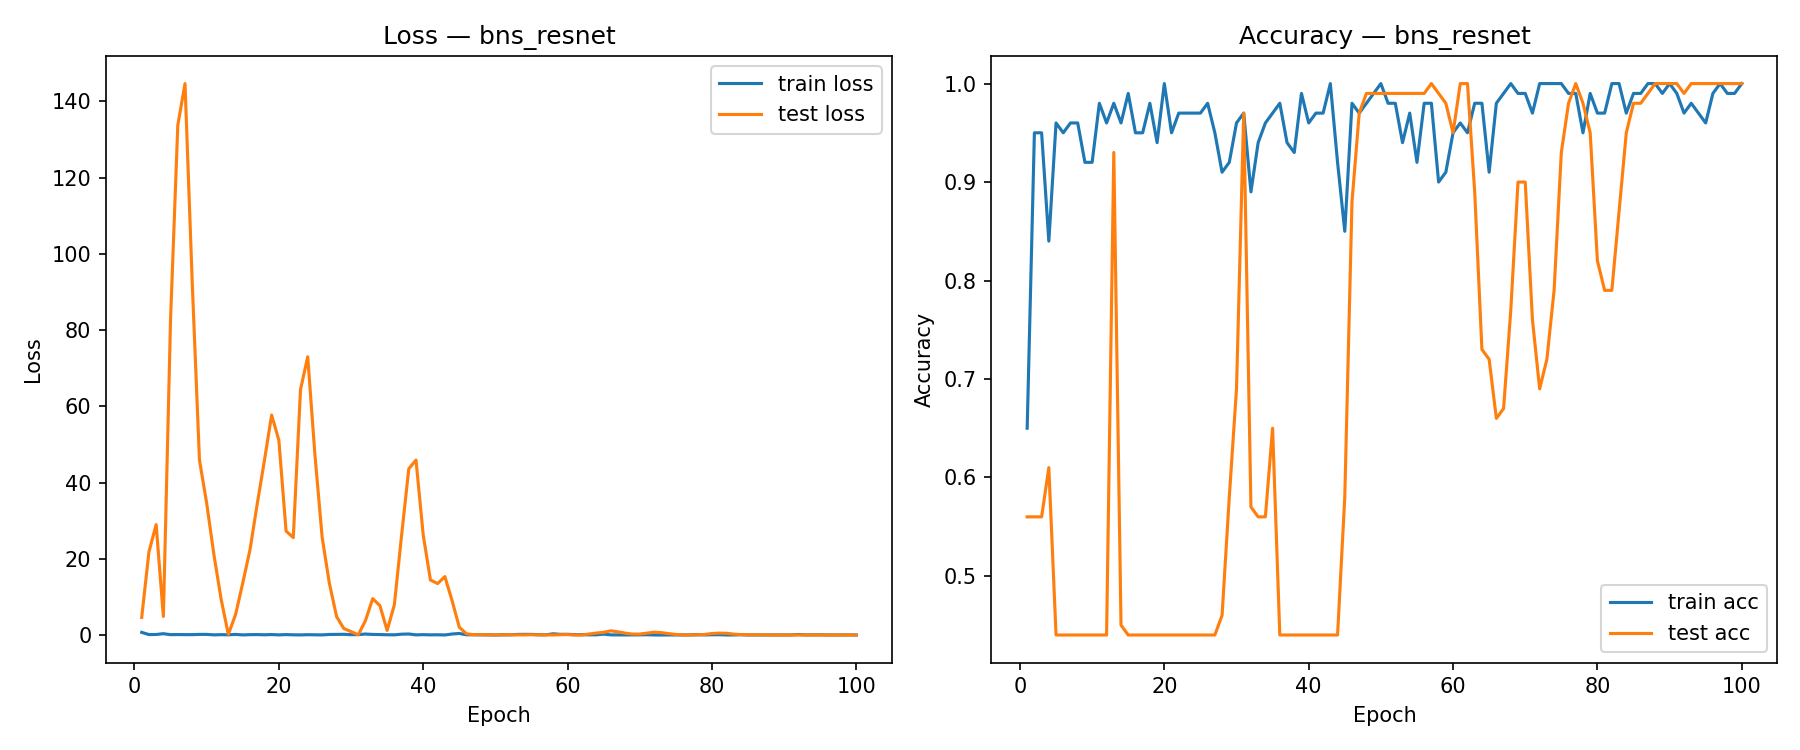

In [7]:
%matplotlib inline
from IPython.display import Image, display
from train_gw_search import plot_loss_history

if history:
    plot_loss_history(history, checkpoint_dir, label='bns_resnet')
    loss_path = Path(checkpoint_dir) / 'loss_history_bns_resnet.png'
    if loss_path.exists():
        display(Image(filename=str(loss_path)))
else:
    print('训练历史不存在, 请先运行训练')

## 6. BNS ROC 曲线

Evaluating SNRs: 100%|██████████| 4/4 [04:33<00:00, 68.41s/it]

ROC plot saved to checkpoints_bns_resnet/roc_bns.png


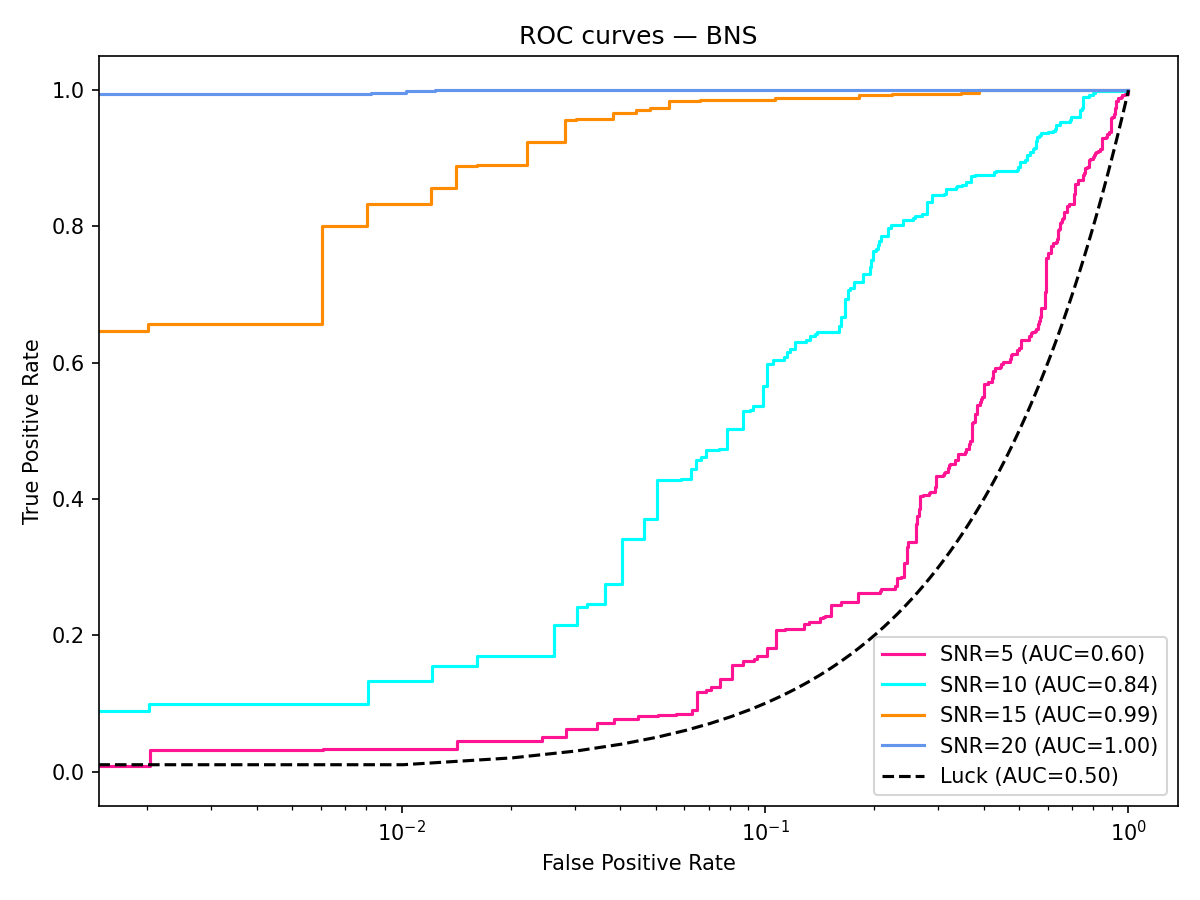

In [8]:
%matplotlib inline
from IPython.display import Image, display
from train_gw_search import plot_roc

plot_roc(net, source='bns', reshape_for_resnet=True, device=device, outdir=checkpoint_dir)

roc_path = Path(checkpoint_dir) / 'roc_bns.png'
if roc_path.exists():
    display(Image(filename=str(roc_path)))
else:
    print('ROC 图未找到, 请先运行训练和评估')

## 7. 结果

本 notebook 直接复用 `train_gw_search.py` 中的 loss/ROC 绘图函数，因此这里展示的曲线与正式脚本保持一致。

如果重新运行训练或重新生成评估数据，曲线细节和 AUC 会有轻微随机波动，因此应以当前生成的 `checkpoints_bns_resnet/loss_history_bns_resnet.png` 与 `checkpoints_bns_resnet/roc_bns.png` 为准。

**双中子星旋近引力波信号搜寻任务完成。**